<!-- project-notebook-context -->
# Image Restoration Benchmark - Impulse Noise Filtering Legacy Notebook

**Current project:** `image-restoration-benchmark`

**Notebook role:** Legacy notebook that originally explored salt-and-pepper noise and median filtering. Its ideas are now part of the unified restoration benchmark pipeline.

## Current project entry points

- `image_restoration_benchmark/noise.py`
- `image_restoration_benchmark/filters.py`
- `scripts/run_benchmark.py`

## Maintenance notes

- This notebook is kept for traceability.
- Use the project-level benchmark for current reproducible results.

---



In [1]:
import numpy as np
import cv2 as cv

In [2]:
# --- Reproducible-run setup (uses an open-source natural sample image) ---
import os, warnings
from pathlib import Path
import numpy as np
import cv2 as cv

warnings.filterwarnings('ignore')
_NB_DIR = Path.cwd()
_RUN_DIR = (_NB_DIR / '..' / 'outputs').resolve()
_RUN_DIR.mkdir(parents=True, exist_ok=True)
_SRC = (_NB_DIR / '../sample/baboon.jpg').resolve()


def _prepare_input(name, max_side=160):
    img = cv.imread(str(_SRC))
    if img is None:
        raise FileNotFoundError(f'Natural sample image not found: {_SRC}')
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    if s < 1.0:
        img = cv.resize(img, (int(w * s), int(h * s)), interpolation=cv.INTER_AREA)
    dst = _RUN_DIR / name
    cv.imwrite(str(dst), img)
    print('Using natural sample:', _SRC.name, '->', img.shape)
    return dst


_prepare_input('1.jpg')
os.chdir(_RUN_DIR)
print('Run dir:', _RUN_DIR)


Using natural sample: baboon.jpg -> (160, 160, 3)
Run dir: C:\work\p\github-repos\private\image-restoration-benchmark\legacy\impulse-noise-filtering\outputs


In [3]:
image = cv.imread('1.jpg')

In [4]:
def salt_pepper_noise(image):
    img = np.copy(image)
    size = img.size
    num_salt = np.ceil(0.1*0.5*size).astype('int')
    num_pepper = np.ceil(0.1*0.5*size).astype('int')
    row , column = img.shape[:2]
    
    x = np.random.randint(0,column-1,num_pepper)
    y = np.random.randint(0,row-1,num_pepper)
    img[y,x] = 0 #pepper noise
    
    x = np.random.randint(0,column-1,num_salt)
    y = np.random.randint(0,row-1,num_salt)
    img[y,x] = 255 #salt noise
    
    return img

In [5]:
def median_filter(image,size):
    H,W,C = image.shape    
    
    pad = size // 2
    
    out = np.zeros((H + pad*2, W + pad*2, C), dtype=np.float64)
    
    out[pad:pad+H, pad:pad+W] = image.copy().astype(np.float64)
    
    tmp = out.copy()

    for y in range(H):
        for x in range(W):
            for c in range(C):
                out[pad+y, pad+x, c] = np.median(tmp[y:y+size, x:x+size, c])
    
    out = out[pad:pad+H, pad:pad+W].astype(np.uint8)
    
    return out

In [6]:
image1 = salt_pepper_noise(image)

image2 = salt_pepper_noise(image)

In [7]:
cv.imwrite("noise.jpg", image1)

True

In [8]:
p3_1 = median_filter(image1,3)

p3_2 = median_filter(p3_1,3)

cv.imwrite("p3.jpg", p3_2)

True

In [9]:
p5 = median_filter(image2,5)

cv.imwrite("p5.jpg", p5)

True

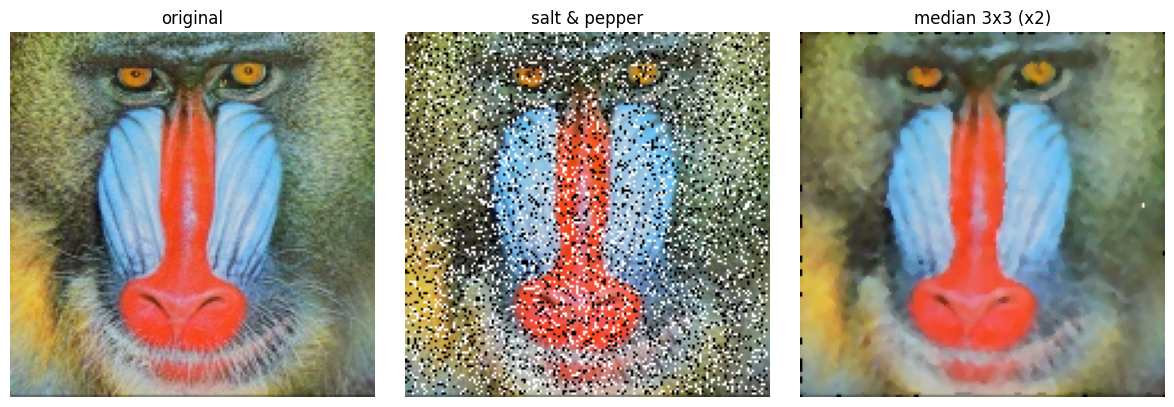

Artifacts written to C:\work\p\github-repos\private\image-restoration-benchmark\legacy\impulse-noise-filtering\outputs


In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, im, t in zip(ax, [image, image1, p3_2], ['original', 'salt & pepper', 'median 3x3 (x2)']):
    a.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB)); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()
print('Artifacts written to', _RUN_DIR)